/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


Stage  1 → RMSE=0.8789, R²=0.7725, CosSim=0.9268
Stage  2 → RMSE=0.8850, R²=0.7832, CosSim=0.9293
Stage  3 → RMSE=0.8859, R²=0.7849, CosSim=0.9296
Stage  4 → RMSE=0.8859, R²=0.7847, CosSim=0.9296
Stage  5 → RMSE=0.8898, R²=0.7917, CosSim=0.9322
Stage  6 → RMSE=0.8945, R²=0.8002, CosSim=0.9351
Stage  7 → RMSE=0.8949, R²=0.8008, CosSim=0.9353
Stage  8 → RMSE=0.8959, R²=0.8026, CosSim=0.9359
Stage  9 → RMSE=0.8960, R²=0.8027, CosSim=0.9360
Stage 10 → RMSE=0.8963, R²=0.8034, CosSim=0.9363

Stage |    RMSE   |    R²    |  CosineSim
------+------+----------+-------------
   1  |   0.8789 |  0.7725 |      0.9268
   2  |   0.8850 |  0.7832 |      0.9293
   3  |   0.8859 |  0.7849 |      0.9296
   4  |   0.8859 |  0.7847 |      0.9296
   5  |   0.8898 |  0.7917 |      0.9322
   6  |   0.8945 |  0.8002 |      0.9351
   7  |   0.8949 |  0.8008 |      0.9353
   8  |   0.8959 |  0.8026 |      0.9359
   9  |   0.8960 |  0.8027 |      0.9360
  10  |   0.8963 |  0.8034 |      0.9363


RMSE: 0.33
R² Score: 0.84
Cosine Similarity: 0.9487


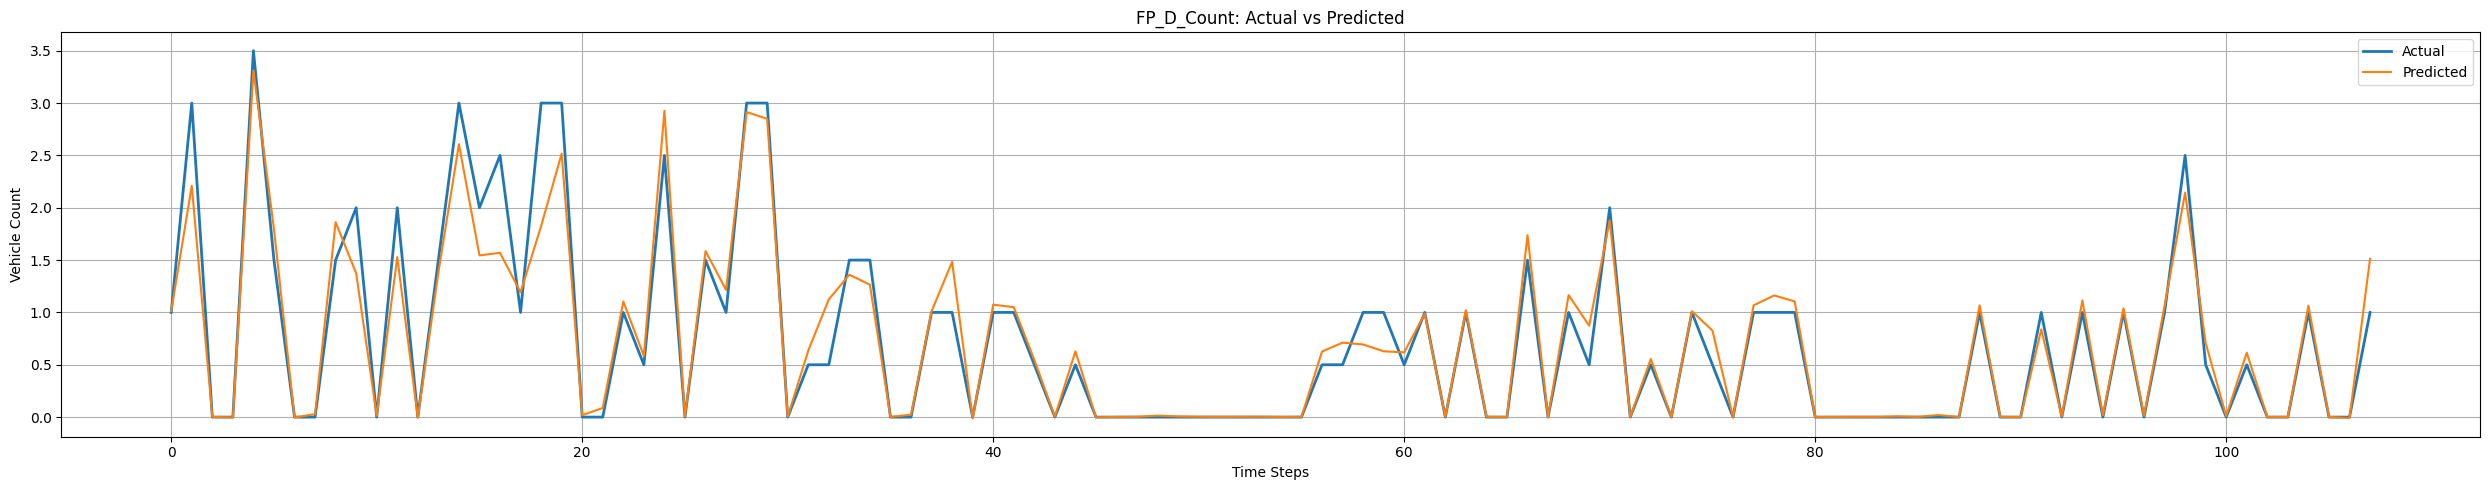

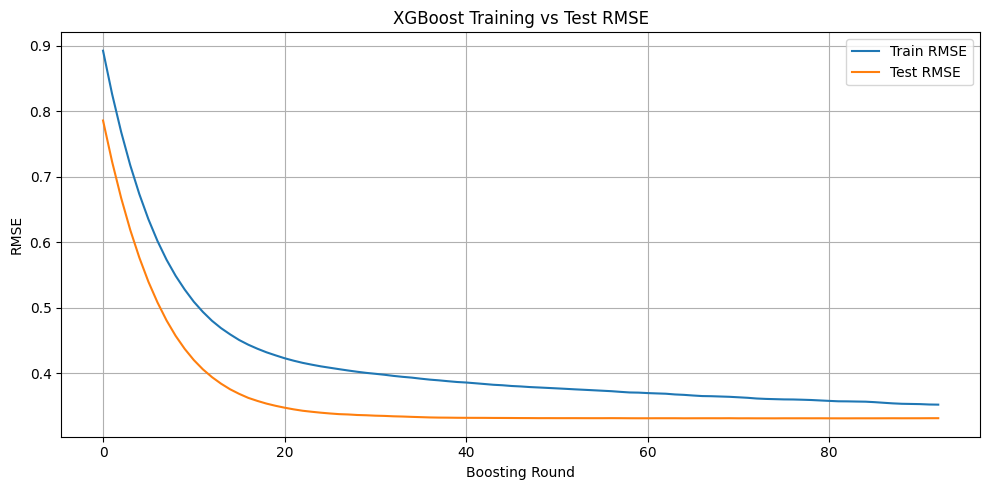

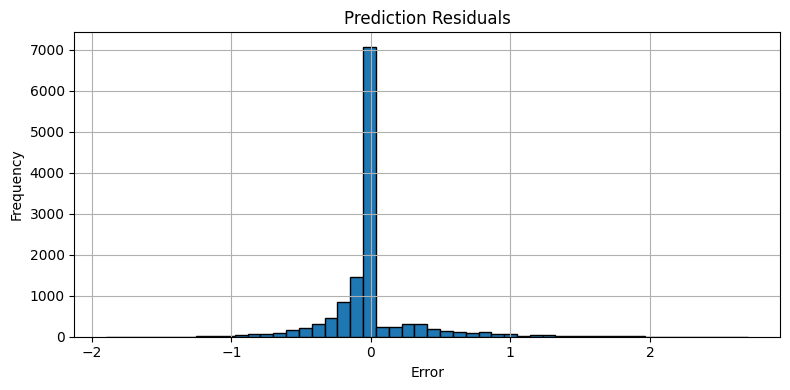

<Figure size 1000x6000 with 0 Axes>

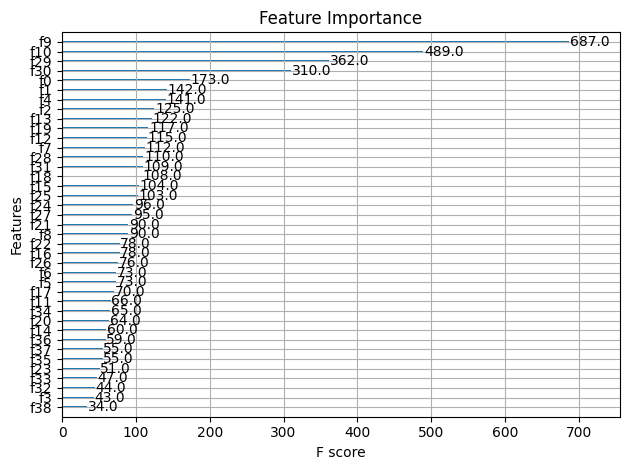

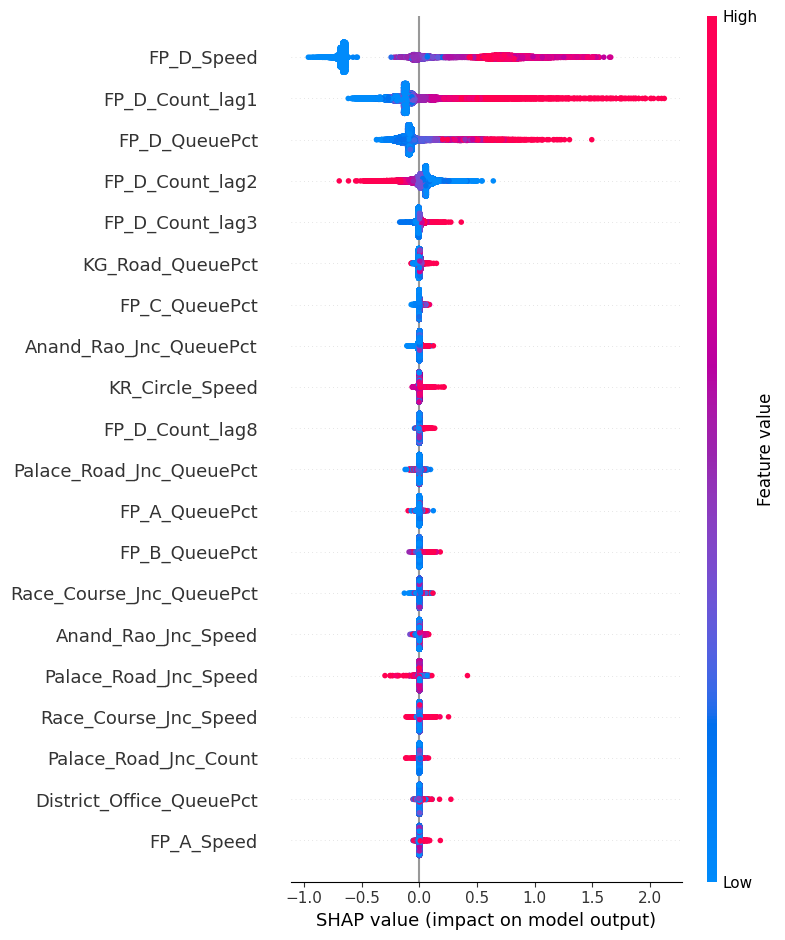

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error as mse, r2_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import shap
import xgboost as xgb

# 1. Load data
f = r'/content/junction_data_race_course (1).csv'
df = pd.read_csv(f)

# 2. Drop Time column if exists
if 'Time' in df.columns:
    df.drop(columns=['Time'], inplace=True)

# 3. Sample by averaging every sample_n rows
sample_n = 2
df = df.groupby(df.index // sample_n).mean().reset_index(drop=True)

# 4. Create lag features for FP_D_Count
n_lags = 10
for lag in range(1, n_lags + 1):
    df[f'FP_D_Count_lag{lag}'] = df['FP_D_Count'].shift(lag)
df.dropna(inplace=True)  # remove rows with NaNs from shifting

# 5. Split into X (features) and y (target)
y = df['FP_D_Count']
X = df.drop(columns=['FP_D_Count'])

# 6. Scale features (helps model convergence and cosine similarity)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. Time-based train/test split (70/30)
split_idx = int(0.7 * len(df))
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# 8. Instantiate XGBRegressor with eval_metric & early_stopping_rounds
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.1,
    random_state=42,
    eval_metric='rmse',
    early_stopping_rounds=10
)

# 9. Fit with eval_set only
eval_set = [(X_train, y_train), (X_test, y_test)]
model.fit(X_train, y_train, eval_set=eval_set, verbose=False)

# 10. Make predictions
y_pred = model.predict(X_test)

# 11. Evaluate
rmse = np.sqrt(mse(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
cos_sim = cosine_similarity([y_test.values], [y_pred])[0][0]

# Print Evaluation Metrics
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.2f}')
print(f'Cosine Similarity: {cos_sim:.4f}')

# 12. Plot: Actual vs Predicted
plt.figure(figsize=(25,5))
plt.plot(y_test.values[::120], label='Actual', linewidth=2)
plt.plot(y_pred[::120], label='Predicted')
plt.title('FP_D_Count: Actual vs Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Vehicle Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')  # Save the plot
plt.show()

# 13. Plot: Train vs Test RMSE over boosting rounds
results = model.evals_result()
epochs = len(results['validation_0']['rmse'])
x_axis = range(epochs)

plt.figure(figsize=(10,5))
plt.plot(x_axis, results['validation_0']['rmse'], label='Train RMSE')
plt.plot(x_axis, results['validation_1']['rmse'], label='Test RMSE')
plt.title('XGBoost Training vs Test RMSE')
plt.xlabel('Boosting Round')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('train_vs_test_rmse.png')  # Save the plot
plt.show()

# 14. Plot: Residuals histogram
residuals = y_test - y_pred
plt.figure(figsize=(8,4))
plt.hist(residuals, bins=50, edgecolor='black')
plt.title('Prediction Residuals')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.savefig('residuals_histogram.png')  # Save the plot
plt.show()

# 15. Feature Importance Plot (using XGBoost's plot_importance)
plt.figure(figsize=(10,60))
xgb.plot_importance(model, importance_type='weight', max_num_features=len(X.columns))
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')  # Save the plot
plt.show()

# 16. SHAP Summary Plot
X_train_df = pd.DataFrame(X_train, columns=X.columns)

# Create SHAP explainer with the original data and the model
explainer = shap.Explainer(model)

# Get SHAP values
shap_values = explainer(X_train_df)

# SHAP summary plot
shap.summary_plot(shap_values, X_train_df)
plt.savefig('shap_summary_plot.png')  # Save the plot
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error as mse, r2_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import shap
import xgboost as xgb

# 1. Load data
f = r'/content/junction_data_race_course (1).csv'
df = pd.read_csv(f)

# 2. Drop Time column if exists
if 'Time' in df.columns:
    df.drop(columns=['Time'], inplace=True)

# 3. Sample by averaging every sample_n rows
sample_n = 2
df = df.groupby(df.index // sample_n).mean().reset_index(drop=True)

# 4. Create lag features for FP_D_Count
n_lags = 10
for lag in range(1, n_lags + 1):
    df[f'FP_D_Count_lag{lag}'] = df['FP_D_Count'].shift(lag)
df.dropna(inplace=True)  # remove rows with NaNs from shifting

# 5. Split into X (features) and y (target)
y = df['FP_D_Count']
X = df.drop(columns=['FP_D_Count'])

# 6. Scale features (helps model convergence and cosine similarity)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. Time-based train/test split (70/30)
split_idx = int(0.7 * len(df))
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]



out_dir = "stage_plots"
os.makedirs(out_dir, exist_ok=True)

# split training into 10 equal parts
X_parts = np.array_split(X_train, 10)
y_parts = np.array_split(y_train, 10)

# fixed test set as DMatrix
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'learning_rate': 0.1,
    'seed': 42,
}

metrics = []
prev_model = None

for stage in range(1, 11):
    # cumulative training data up to this stage
    X_chunk = np.vstack(X_parts[:stage])
    y_chunk = np.hstack(y_parts[:stage])
    dtrain = xgb.DMatrix(X_chunk, label=y_chunk)

    # prepare a dict to collect eval results
    evals_result = {}

    # warm‑start training, filling evals_result
    booster = xgb.train(
        params,
        dtrain,
        num_boost_round=500,
        evals=[(dtrain, 'train'), (dtest, 'test')],
        early_stopping_rounds=10,
        evals_result=evals_result,        # <-- capture metrics here
        verbose_eval=False,
        xgb_model=prev_model
    )
    prev_model = booster

    # compute metrics on fixed test set
    y_pred = booster.predict(dtest)
    rmse = np.sqrt(r2_score(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    cos  = cosine_similarity([y_test.values], [y_pred])[0][0]
    metrics.append((stage, rmse, r2, cos))

    # --- 1) Validation curve plot ---
    epochs = len(evals_result['train']['rmse'])
    plt.figure(figsize=(8,4))
    plt.plot(range(epochs), evals_result['train']['rmse'], label='Train RMSE')
    plt.plot(range(epochs), evals_result['test']['rmse'],  label='Test RMSE')
    plt.title(f'Stage {stage}: RMSE vs Boosting Round')
    plt.xlabel('Boosting Round')
    plt.ylabel('RMSE')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'{out_dir}/stage{stage}_val_curve.png')
    plt.close()

    # --- 2) Actual vs Predicted plot ---
    plt.figure(figsize=(10,3))
    plt.plot(y_test.values, label='Actual', linewidth=1)
    plt.plot(y_pred,      label='Predicted', linewidth=1)
    plt.title(f'Stage {stage}: Actual vs Predicted')
    plt.xlabel('Test sample index')
    plt.ylabel('FP_D_Count')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'{out_dir}/stage{stage}_act_vs_pred.png')
    plt.close()

    print(f"Stage {stage:2d} → RMSE={rmse:.4f}, R²={r2:.4f}, CosSim={cos:.4f}")

# summary
print("\nStage |    RMSE   |    R²    |  CosineSim")
print("------+------+----------+-------------")
for s, rmse, r2, cos in metrics:
    print(f"  {s:2d}  | {rmse:8.4f} | {r2:7.4f} | {cos:11.4f}")

/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


Stage  1 → RMSE=0.8789, R²=0.7725, CosSim=0.9268
Stage  2 → RMSE=0.8850, R²=0.7832, CosSim=0.9293
Stage  3 → RMSE=0.8859, R²=0.7849, CosSim=0.9296
Stage  4 → RMSE=0.8859, R²=0.7847, CosSim=0.9296
Stage  5 → RMSE=0.8898, R²=0.7917, CosSim=0.9322
Stage  6 → RMSE=0.8945, R²=0.8002, CosSim=0.9351
Stage  7 → RMSE=0.8949, R²=0.8008, CosSim=0.9353
Stage  8 → RMSE=0.8959, R²=0.8026, CosSim=0.9359
Stage  9 → RMSE=0.8960, R²=0.8027, CosSim=0.9360
Stage 10 → RMSE=0.8963, R²=0.8034, CosSim=0.9363

Stage |    RMSE   |    R²    |  CosineSim
------+------+----------+-------------
   1  |   0.8789 |  0.7725 |      0.9268
   2  |   0.8850 |  0.7832 |      0.9293
   3  |   0.8859 |  0.7849 |      0.9296
   4  |   0.8859 |  0.7847 |      0.9296
   5  |   0.8898 |  0.7917 |      0.9322
   6  |   0.8945 |  0.8002 |      0.9351
   7  |   0.8949 |  0.8008 |      0.9353
   8  |   0.8959 |  0.8026 |      0.9359
   9  |   0.8960 |  0.8027 |      0.9360
  10  |   0.8963 |  0.8034 |      0.9363


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error as mse, r2_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import shap
import xgboost as xgb

# 1. Load data
f = r'/content/junction_data_race_course (1).csv'
df = pd.read_csv(f)

# 2. Drop Time column if exists
if 'Time' in df.columns:
    df.drop(columns=['Time'], inplace=True)

# 3. Sample by averaging every sample_n rows
sample_n = 2
df = df.groupby(df.index // sample_n).mean().reset_index(drop=True)

# 4. Create lag features for FP_D_Count
n_lags = 10
for lag in range(1, n_lags + 1):
    df[f'FP_D_Count_lag{lag}'] = df['FP_D_Count'].shift(lag)
df.dropna(inplace=True)  # remove rows with NaNs from shifting

# 5. Split into X (features) and y (target)
y = df['FP_D_Count']
X = df.drop(columns=['FP_D_Count'])

# 6. Scale features (helps model convergence and cosine similarity)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. Time-based train/test split (70/30)
split_idx = int(0.7 * len(df))
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]



out_dir = "stage_plots"
os.makedirs(out_dir, exist_ok=True)

# split training into 10 equal parts
X_parts = np.array_split(X_train, 10)
y_parts = np.array_split(y_train, 10)

# fixed test set as DMatrix
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'learning_rate': 0.1,
    'seed': 42,
}

metrics = []
prev_model = None

for stage in range(1, 11):
    # cumulative training data up to this stage
    X_chunk = X_parts[stage - 1]
    y_chunk = y_parts[stage - 1]

    dtrain = xgb.DMatrix(X_chunk, label=y_chunk)

    # prepare a dict to collect eval results
    evals_result = {}

    # warm‑start training, filling evals_result
    booster = xgb.train(
        params,
        dtrain,
        num_boost_round=500,
        evals=[(dtrain, 'train'), (dtest, 'test')],
        early_stopping_rounds=10,
        evals_result=evals_result,        # <-- capture metrics here
        verbose_eval=False,
        xgb_model=prev_model
    )
    prev_model = booster

    # compute metrics on fixed test set
    y_pred = booster.predict(dtest)
    rmse = np.sqrt(r2_score(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    cos  = cosine_similarity([y_test.values], [y_pred])[0][0]
    metrics.append((stage, rmse, r2, cos))

    # --- 1) Validation curve plot ---
    epochs = len(evals_result['train']['rmse'])
    plt.figure(figsize=(8,4))
    plt.plot(range(epochs), evals_result['train']['rmse'], label='Train RMSE')
    plt.plot(range(epochs), evals_result['test']['rmse'],  label='Test RMSE')
    plt.title(f'Stage {stage}: RMSE vs Boosting Round')
    plt.xlabel('Boosting Round')
    plt.ylabel('RMSE')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'{out_dir}/stage{stage}_val_curve.png')
    plt.close()

    # --- 2) Actual vs Predicted plot ---
    plt.figure(figsize=(10,3))
    plt.plot(y_test.values, label='Actual', linewidth=1)
    plt.plot(y_pred,      label='Predicted', linewidth=1)
    plt.title(f'Stage {stage}: Actual vs Predicted')
    plt.xlabel('Test sample index')
    plt.ylabel('FP_D_Count')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'{out_dir}/stage{stage}_act_vs_pred.png')
    plt.close()

    print(f"Stage {stage:2d} → RMSE={rmse:.4f}, R²={r2:.4f}, CosSim={cos:.4f}")

# summary
print("\nStage |    RMSE   |    R²    |  CosineSim")
print("------+------+----------+-------------")
for s, rmse, r2, cos in metrics:
    print(f"  {s:2d}  | {rmse:8.4f} | {r2:7.4f} | {cos:11.4f}")

/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


Stage  1 → RMSE=0.8789, R²=0.7725, CosSim=0.9268
Stage  2 → RMSE=0.8817, R²=0.7774, CosSim=0.9280
Stage  3 → RMSE=0.8743, R²=0.7644, CosSim=0.9229
Stage  4 → RMSE=0.8650, R²=0.7483, CosSim=0.9176
Stage  5 → RMSE=0.8852, R²=0.7836, CosSim=0.9297
Stage  6 → RMSE=0.8844, R²=0.7821, CosSim=0.9310
Stage  7 → RMSE=0.8812, R²=0.7765, CosSim=0.9298
Stage  8 → RMSE=0.8805, R²=0.7753, CosSim=0.9291
Stage  9 → RMSE=0.8765, R²=0.7683, CosSim=0.9284
Stage 10 → RMSE=0.8758, R²=0.7671, CosSim=0.9276

Stage |    RMSE   |    R²    |  CosineSim
------+------+----------+-------------
   1  |   0.8789 |  0.7725 |      0.9268
   2  |   0.8817 |  0.7774 |      0.9280
   3  |   0.8743 |  0.7644 |      0.9229
   4  |   0.8650 |  0.7483 |      0.9176
   5  |   0.8852 |  0.7836 |      0.9297
   6  |   0.8844 |  0.7821 |      0.9310
   7  |   0.8812 |  0.7765 |      0.9298
   8  |   0.8805 |  0.7753 |      0.9291
   9  |   0.8765 |  0.7683 |      0.9284
  10  |   0.8758 |  0.7671 |      0.9276


#NOW CHECKNG ADJACENT JUNCTIONS

RMSE: 0.21
R² Score: 0.84
Cosine Similarity: 0.9671


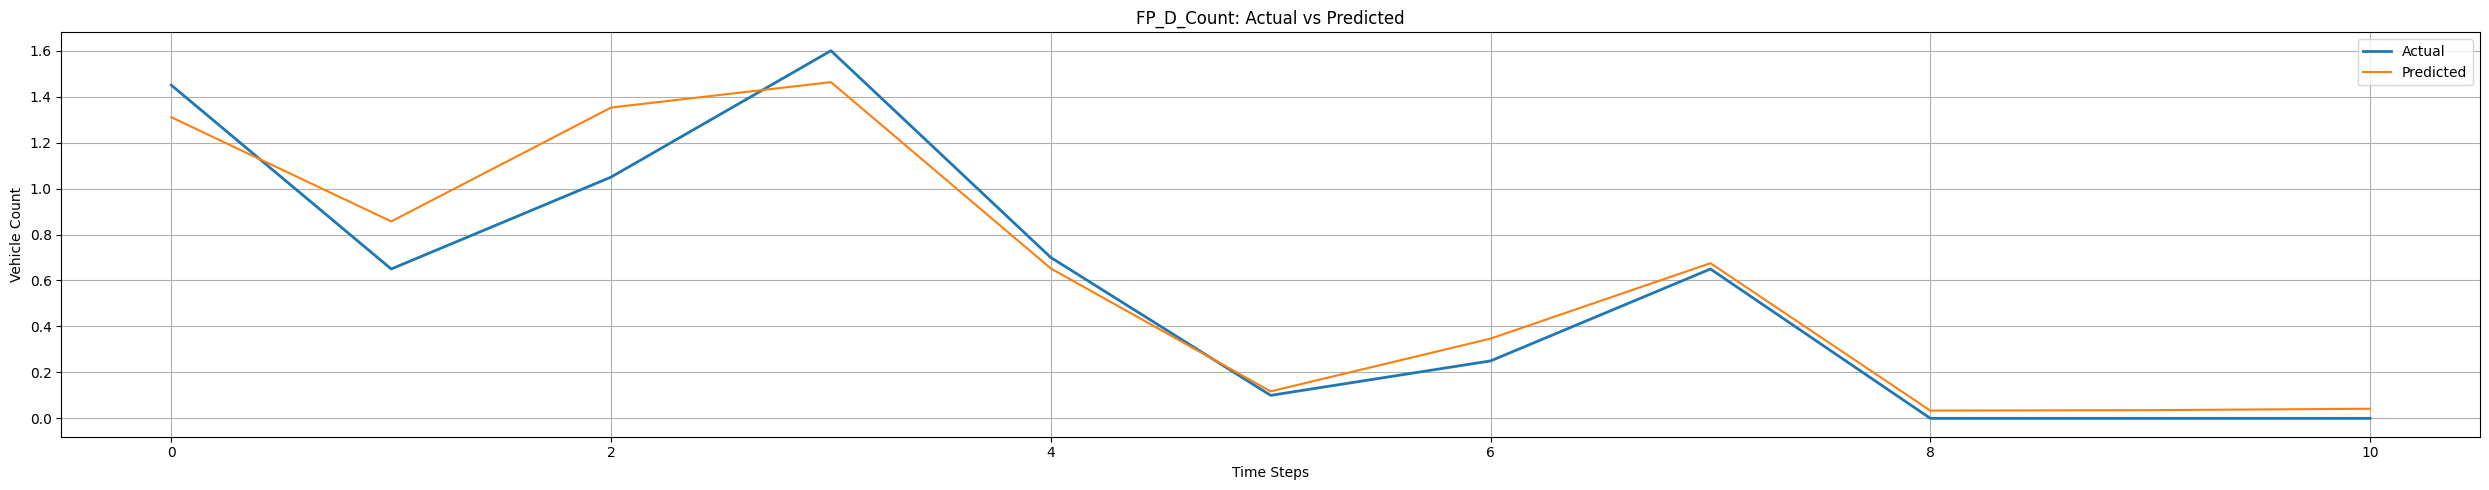

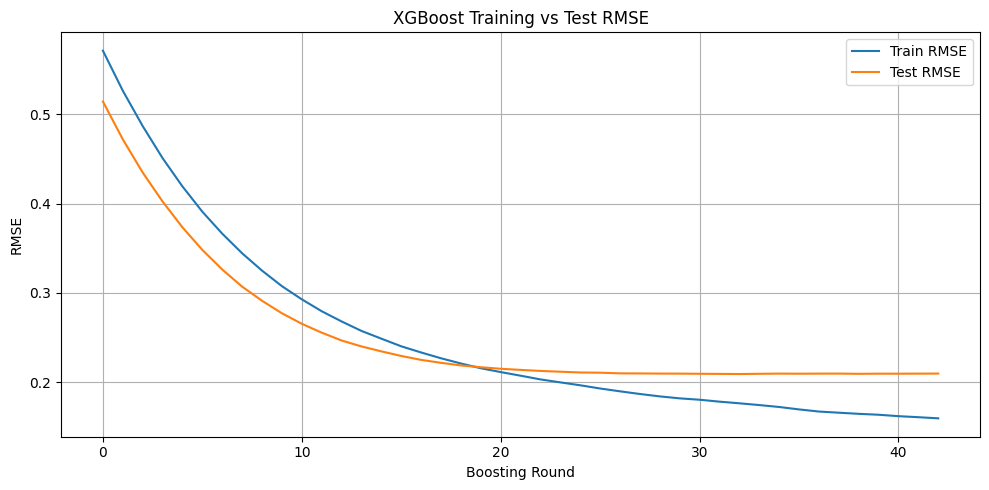

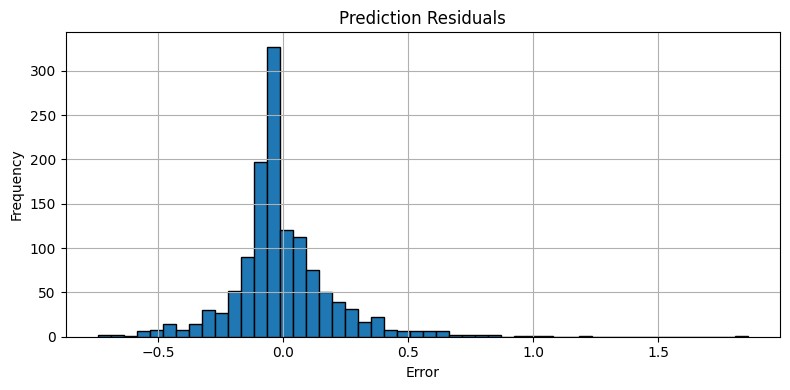

<Figure size 1000x6000 with 0 Axes>

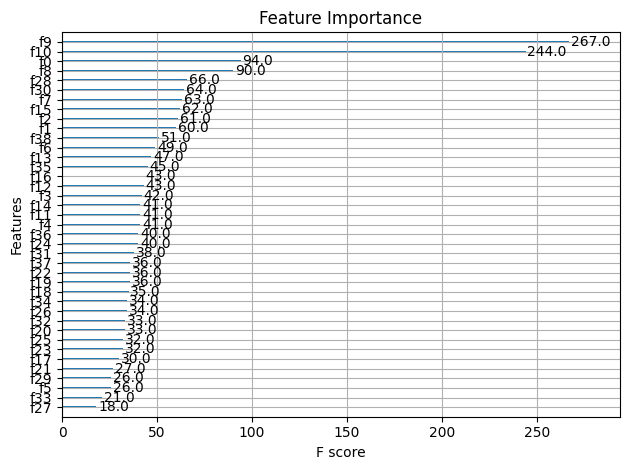

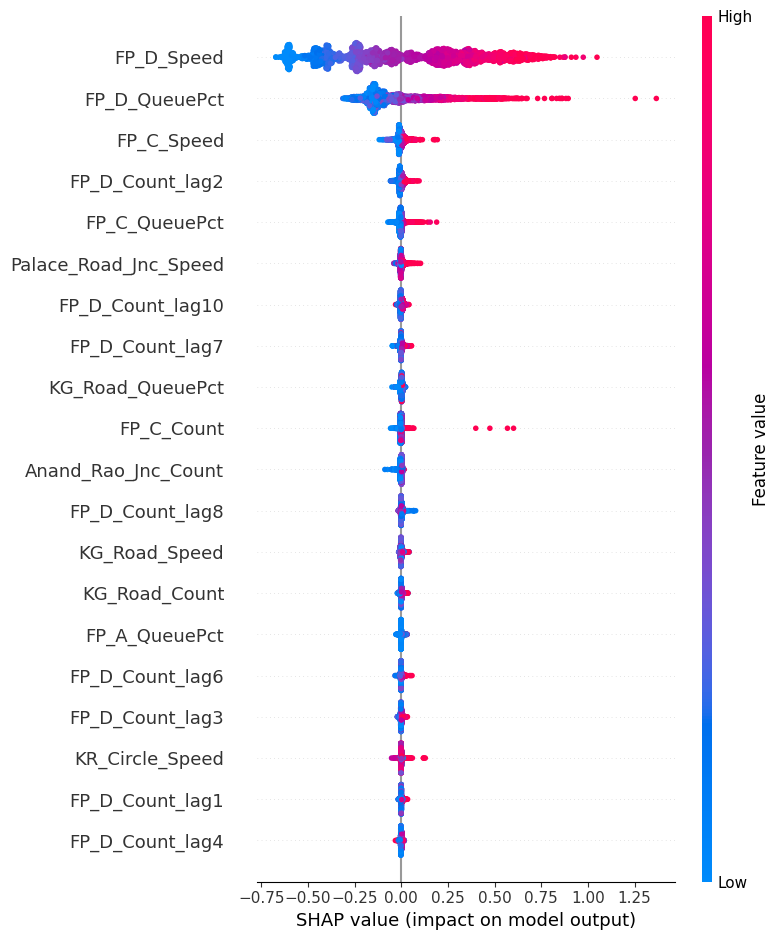

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error as mse, r2_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import shap
import xgboost as xgb

# 1. Load data
f = r'/content/junction_data_race_course (1).csv'
df = pd.read_csv(f)

# 2. Drop Time column if exists
if 'Time' in df.columns:
    df.drop(columns=['Time'], inplace=True)

# 3. Sample by averaging every sample_n rows
sample_n = 20
df = df.groupby(df.index // sample_n).mean().reset_index(drop=True)

# 4. Create lag features for FP_D_Count
n_lags = 10
for lag in range(1, n_lags + 1):
    df[f'FP_D_Count_lag{lag}'] = df['FP_D_Count'].shift(lag)
df.dropna(inplace=True)  # remove rows with NaNs from shifting

# 5. Split into X (features) and y (target)
y = df['FP_D_Count']
X = df.drop(columns=['FP_D_Count'])

# 6. Scale features (helps model convergence and cosine similarity)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. Time-based train/test split (70/30)
split_idx = int(0.7 * len(df))
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# 8. Instantiate XGBRegressor with eval_metric & early_stopping_rounds
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.1,
    random_state=42,
    eval_metric='rmse',
    early_stopping_rounds=10
)

# 9. Fit with eval_set only
eval_set = [(X_train, y_train), (X_test, y_test)]
model.fit(X_train, y_train, eval_set=eval_set, verbose=False)

# 10. Make predictions
y_pred = model.predict(X_test)

# 11. Evaluate
rmse = np.sqrt(mse(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
cos_sim = cosine_similarity([y_test.values], [y_pred])[0][0]

# Print Evaluation Metrics
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.2f}')
print(f'Cosine Similarity: {cos_sim:.4f}')

# 12. Plot: Actual vs Predicted
plt.figure(figsize=(25,5))
plt.plot(y_test.values[::120], label='Actual', linewidth=2)
plt.plot(y_pred[::120], label='Predicted')
plt.title('FP_D_Count: Actual vs Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Vehicle Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')  # Save the plot
plt.show()

# 13. Plot: Train vs Test RMSE over boosting rounds
results = model.evals_result()
epochs = len(results['validation_0']['rmse'])
x_axis = range(epochs)

plt.figure(figsize=(10,5))
plt.plot(x_axis, results['validation_0']['rmse'], label='Train RMSE')
plt.plot(x_axis, results['validation_1']['rmse'], label='Test RMSE')
plt.title('XGBoost Training vs Test RMSE')
plt.xlabel('Boosting Round')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('train_vs_test_rmse.png')  # Save the plot
plt.show()

# 14. Plot: Residuals histogram
residuals = y_test - y_pred
plt.figure(figsize=(8,4))
plt.hist(residuals, bins=50, edgecolor='black')
plt.title('Prediction Residuals')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.savefig('residuals_histogram.png')  # Save the plot
plt.show()

# 15. Feature Importance Plot (using XGBoost's plot_importance)
plt.figure(figsize=(10,60))
xgb.plot_importance(model, importance_type='weight', max_num_features=len(X.columns))
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')  # Save the plot
plt.show()

# 16. SHAP Summary Plot
X_train_df = pd.DataFrame(X_train, columns=X.columns)

# Create SHAP explainer with the original data and the model
explainer = shap.Explainer(model)

# Get SHAP values
shap_values = explainer(X_train_df)

# SHAP summary plot
shap.summary_plot(shap_values, X_train_df)
plt.savefig('shap_summary_plot.png')  # Save the plot
plt.show()


In [ ]:
#FPD COUNT is influenced by its adjacent nodes

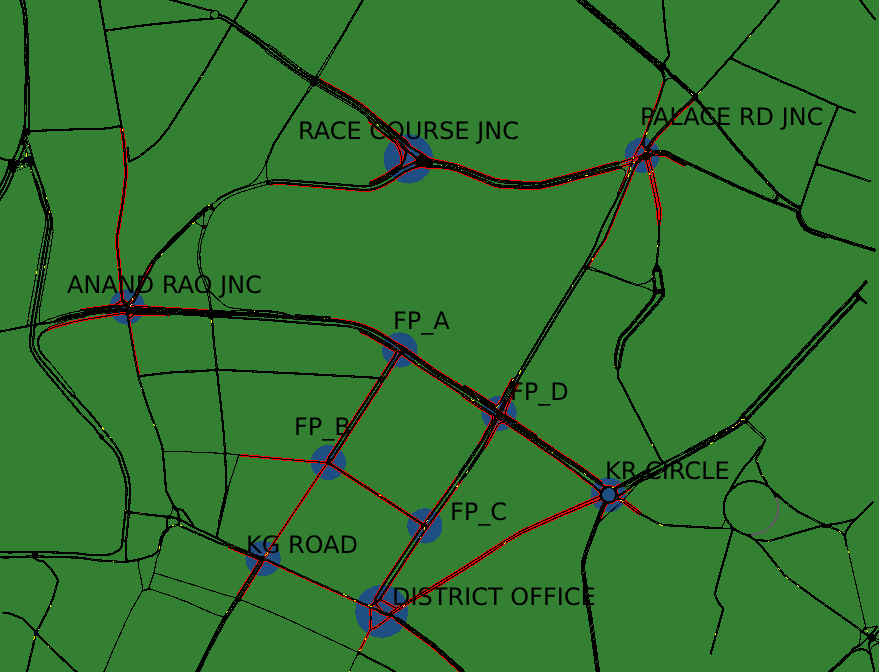

RMSE: 0.33
R² Score: 0.84
Cosine Similarity: 0.9487


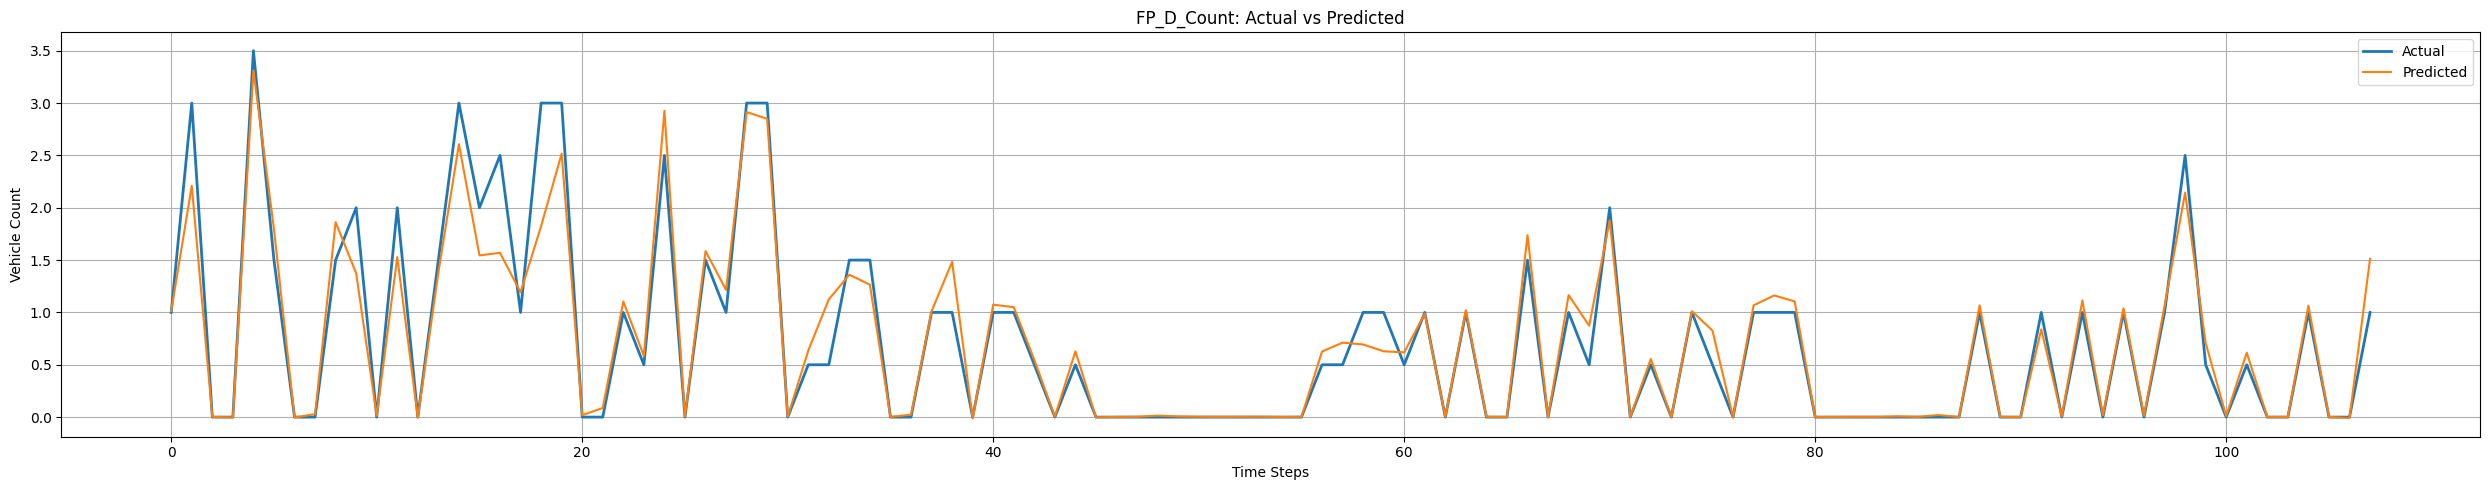

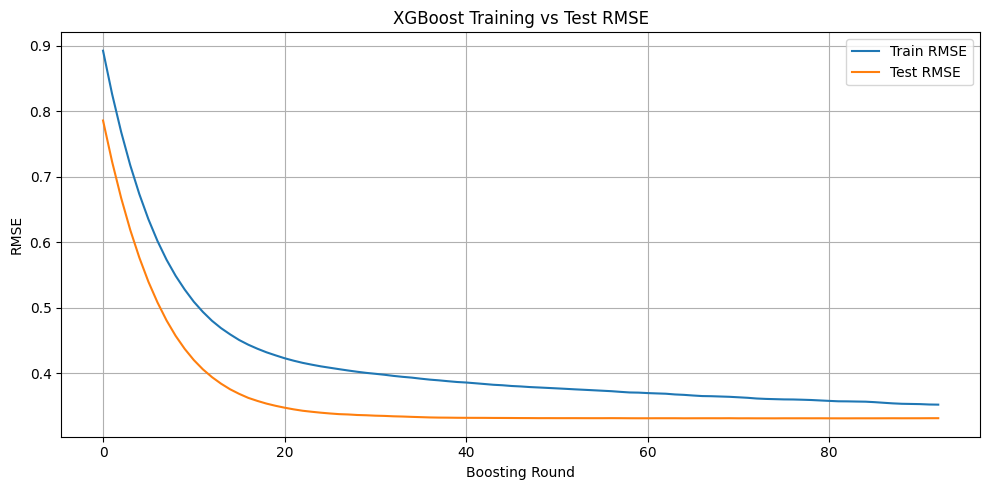

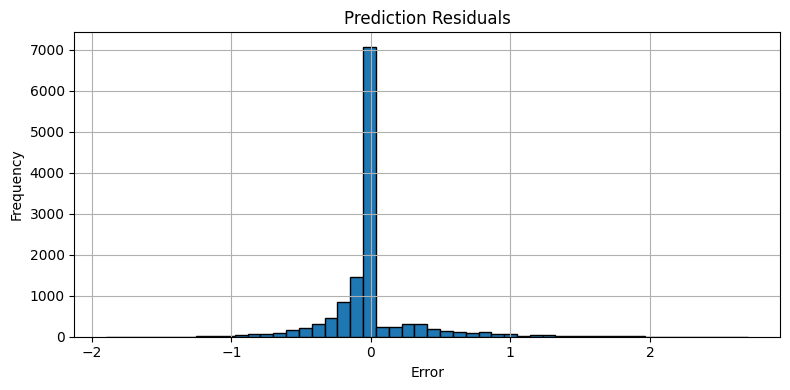

<Figure size 1000x6000 with 0 Axes>

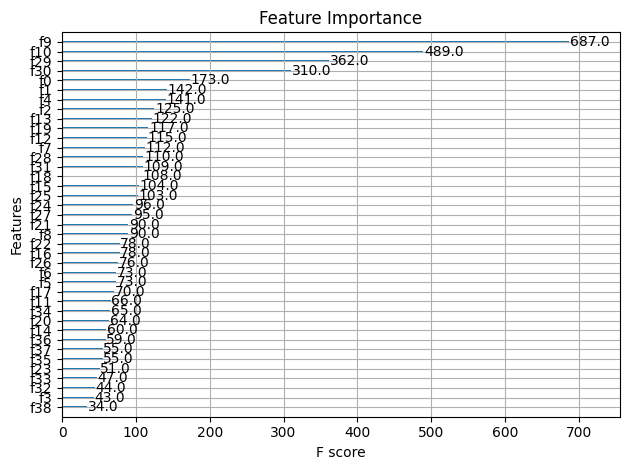

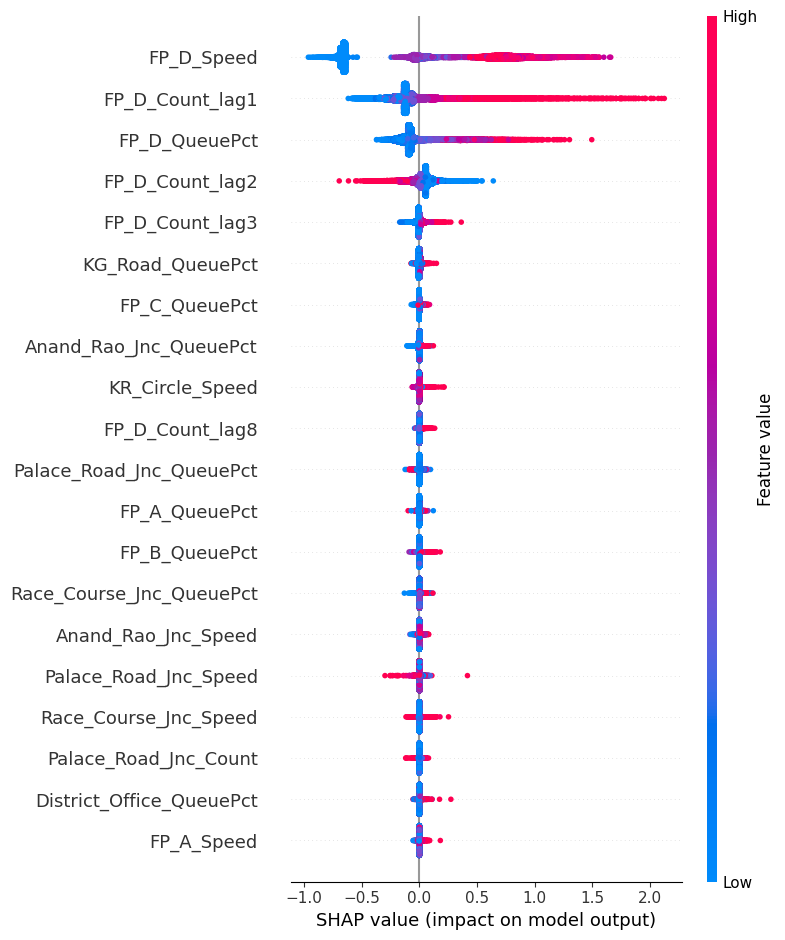

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error as mse, r2_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import shap
import xgboost as xgb

# 1. Load data
f = r'/content/junction_data_race_course (1).csv'
df = pd.read_csv(f)

# 2. Drop Time column if exists
if 'Time' in df.columns:
    df.drop(columns=['Time'], inplace=True)

# 3. Sample by averaging every sample_n rows
sample_n = 2
df = df.groupby(df.index // sample_n).mean().reset_index(drop=True)

# 4. Create lag features for FP_D_Count
n_lags = 10
for lag in range(1, n_lags + 1):
    df[f'FP_D_Count_lag{lag}'] = df['FP_D_Count'].shift(lag)
df.dropna(inplace=True)  # remove rows with NaNs from shifting

# 5. Split into X (features) and y (target)
y = df['FP_D_Count']
X = df.drop(columns=['FP_D_Count'])

# 6. Scale features (helps model convergence and cosine similarity)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. Time-based train/test split (70/30)
split_idx = int(0.7 * len(df))
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# 8. Instantiate XGBRegressor with eval_metric & early_stopping_rounds
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.1,
    random_state=42,
    eval_metric='rmse',
    early_stopping_rounds=10
)

# 9. Fit with eval_set only
eval_set = [(X_train, y_train), (X_test, y_test)]
model.fit(X_train, y_train, eval_set=eval_set, verbose=False)

# 10. Make predictions
y_pred = model.predict(X_test)

# 11. Evaluate
rmse = np.sqrt(mse(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
cos_sim = cosine_similarity([y_test.values], [y_pred])[0][0]

# Print Evaluation Metrics
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.2f}')
print(f'Cosine Similarity: {cos_sim:.4f}')

# 12. Plot: Actual vs Predicted
plt.figure(figsize=(25,5))
plt.plot(y_test.values[::120], label='Actual', linewidth=2)
plt.plot(y_pred[::120], label='Predicted')
plt.title('FP_D_Count: Actual vs Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Vehicle Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')  # Save the plot
plt.show()

# 13. Plot: Train vs Test RMSE over boosting rounds
results = model.evals_result()
epochs = len(results['validation_0']['rmse'])
x_axis = range(epochs)

plt.figure(figsize=(10,5))
plt.plot(x_axis, results['validation_0']['rmse'], label='Train RMSE')
plt.plot(x_axis, results['validation_1']['rmse'], label='Test RMSE')
plt.title('XGBoost Training vs Test RMSE')
plt.xlabel('Boosting Round')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('train_vs_test_rmse.png')  # Save the plot
plt.show()

# 14. Plot: Residuals histogram
residuals = y_test - y_pred
plt.figure(figsize=(8,4))
plt.hist(residuals, bins=50, edgecolor='black')
plt.title('Prediction Residuals')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.savefig('residuals_histogram.png')  # Save the plot
plt.show()

# 15. Feature Importance Plot (using XGBoost's plot_importance)
plt.figure(figsize=(10,60))
xgb.plot_importance(model, importance_type='weight', max_num_features=len(X.columns))
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')  # Save the plot
plt.show()

# 16. SHAP Summary Plot
X_train_df = pd.DataFrame(X_train, columns=X.columns)

# Create SHAP explainer with the original data and the model
explainer = shap.Explainer(model)

# Get SHAP values
shap_values = explainer(X_train_df)

# SHAP summary plot
shap.summary_plot(shap_values, X_train_df)
plt.savefig('shap_summary_plot.png')  # Save the plot
plt.show()


RMSE: 0.33
R² Score: 0.84
Cosine Similarity: 0.9487


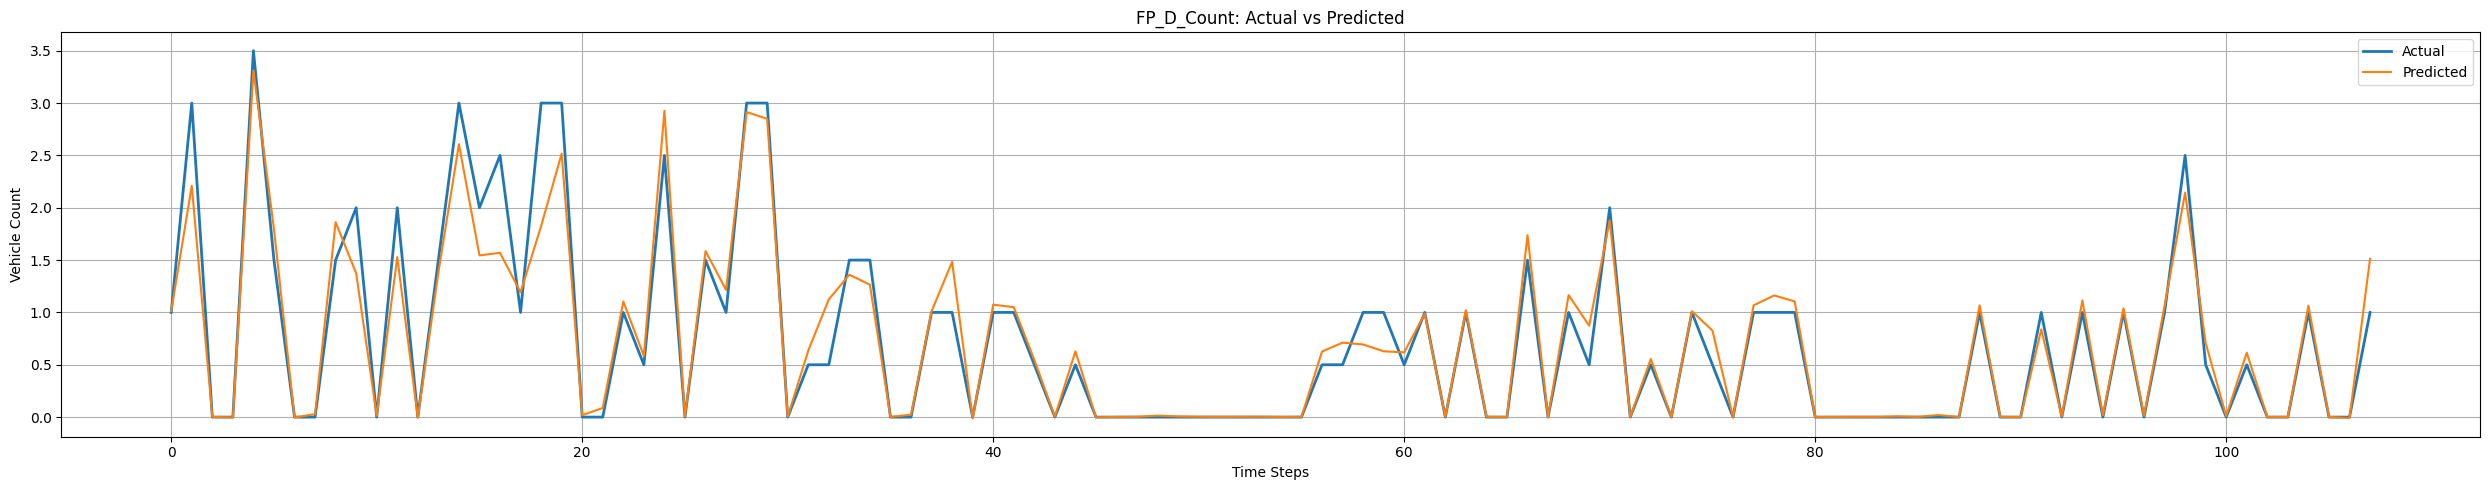

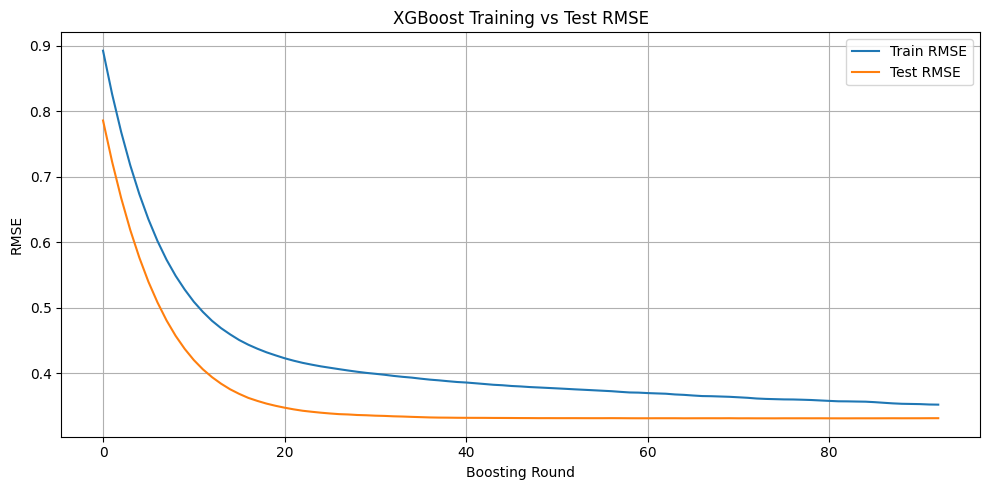

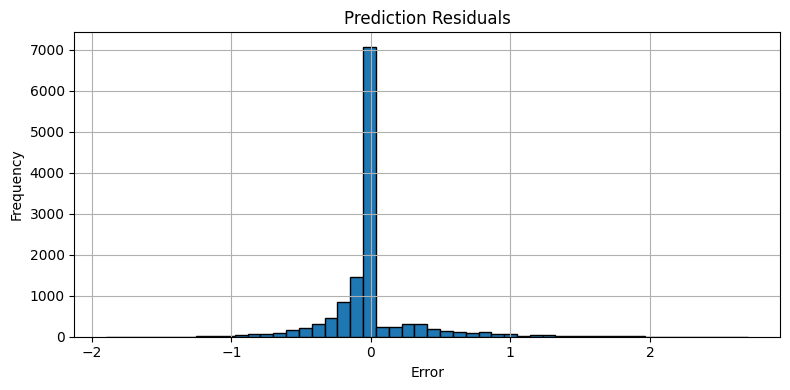

<Figure size 1000x6000 with 0 Axes>

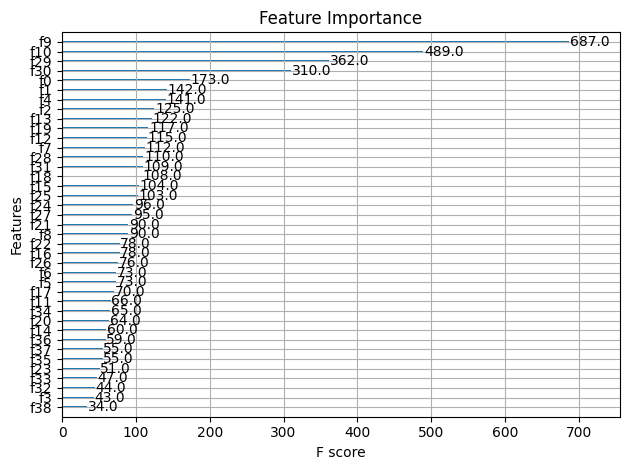

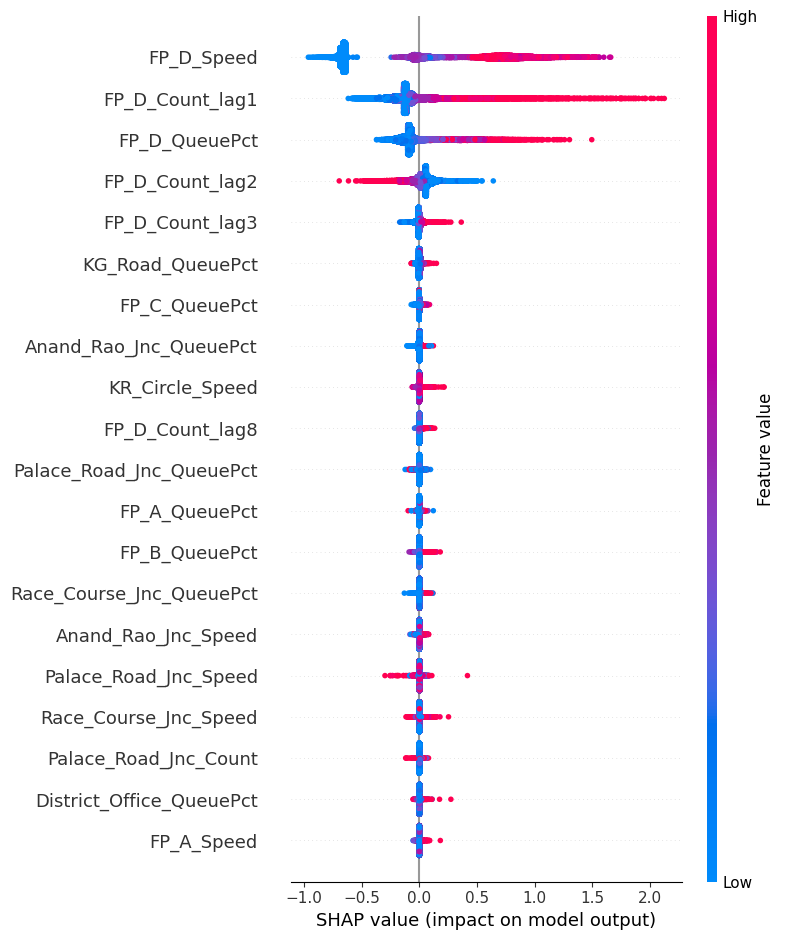

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error as mse, r2_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import shap
import xgboost as xgb


# 1. Load data
f = r'/content/junction_data_race_course (1).csv'
df = pd.read_csv(f)

# 2. Drop Time column if exists
if 'Time' in df.columns:
    df.drop(columns=['Time'], inplace=True)

# 3. Sample by averaging every sample_n rows
sample_n = 2
df = df.groupby(df.index // sample_n).mean().reset_index(drop=True)

# 4. Create lag features for FP_D_Count
n_lags = 10
for lag in range(1, n_lags + 1):
    df[f'FP_D_Count_lag{lag}'] = df['FP_D_Count'].shift(lag)
df.dropna(inplace=True)

# 5. Keep only features from FP_A, FP_C, KR_Circle, Palace_Road + FP_D_Count and its lags
prefixes = [
    'FP_A_', 'FP_B_', 'FP_C_', 'KR_Circle_', 'KG_Road_',
    'District_Office_', 'Anand_Rao_Jnc_', 'Race_Course_Jnc_', 'Palace_Road_Jnc_'
]
keep_cols = [col for col in df.columns if any(col.startswith(p) for p in prefixes) or col.startswith('FP_D_Count')]
#df = df[keep_cols]

# 6. Split into X and y
y = df['FP_D_Count']
X = df.drop(columns=['FP_D_Count'])


# 6. Scale features (helps model convergence and cosine similarity)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. Time-based train/test split (70/30)
split_idx = int(0.7 * len(df))
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# 8. Instantiate XGBRegressor with eval_metric & early_stopping_rounds
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.1,
    random_state=42,
    eval_metric='rmse',
    early_stopping_rounds=10
)

# 9. Fit with eval_set only
eval_set = [(X_train, y_train), (X_test, y_test)]
model.fit(X_train, y_train, eval_set=eval_set, verbose=False)

# 10. Make predictions
y_pred = model.predict(X_test)

# 11. Evaluate
rmse = np.sqrt(mse(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
cos_sim = cosine_similarity([y_test.values], [y_pred])[0][0]

# Print Evaluation Metrics
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.2f}')
print(f'Cosine Similarity: {cos_sim:.4f}')

# 12. Plot: Actual vs Predicted
plt.figure(figsize=(25,5))
plt.plot(y_test.values[::120], label='Actual', linewidth=2)
plt.plot(y_pred[::120], label='Predicted')
plt.title('FP_D_Count: Actual vs Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Vehicle Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')  # Save the plot
plt.show()

# 13. Plot: Train vs Test RMSE over boosting rounds
results = model.evals_result()
epochs = len(results['validation_0']['rmse'])
x_axis = range(epochs)

plt.figure(figsize=(10,5))
plt.plot(x_axis, results['validation_0']['rmse'], label='Train RMSE')
plt.plot(x_axis, results['validation_1']['rmse'], label='Test RMSE')
plt.title('XGBoost Training vs Test RMSE')
plt.xlabel('Boosting Round')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('train_vs_test_rmse.png')  # Save the plot
plt.show()

# 14. Plot: Residuals histogram
residuals = y_test - y_pred
plt.figure(figsize=(8,4))
plt.hist(residuals, bins=50, edgecolor='black')
plt.title('Prediction Residuals')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.savefig('residuals_histogram.png')  # Save the plot
plt.show()

# 15. Feature Importance Plot (using XGBoost's plot_importance)
plt.figure(figsize=(10,60))
xgb.plot_importance(model, importance_type='weight', max_num_features=len(X.columns))
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')  # Save the plot
plt.show()

# 16. SHAP Summary Plot
X_train_df = pd.DataFrame(X_train, columns=X.columns)

# Create SHAP explainer with the original data and the model
explainer = shap.Explainer(model)

# Get SHAP values
shap_values = explainer(X_train_df)

# SHAP summary plot
shap.summary_plot(shap_values, X_train_df)
plt.savefig('shap_summary_plot.png')  # Save the plot
plt.show()


In [ ]:
ls = ['a', 'b', 'c']  - ['a']

TypeError: unsupported operand type(s) for -: 'list' and 'list'

#CHECKING IF Other features lags help

RMSE: 0.30
R² Score: 0.89
Cosine Similarity: 0.9618


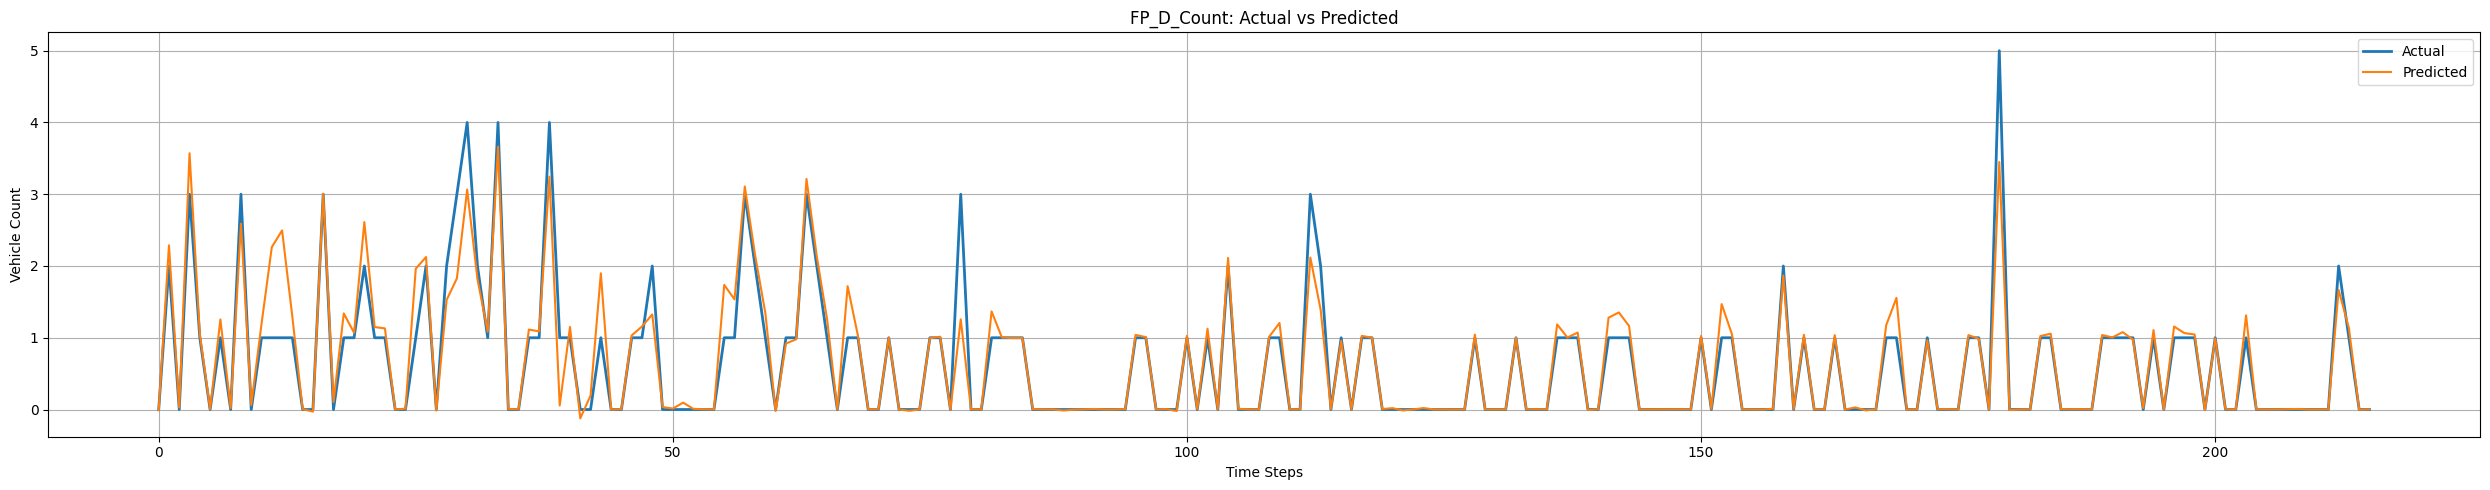

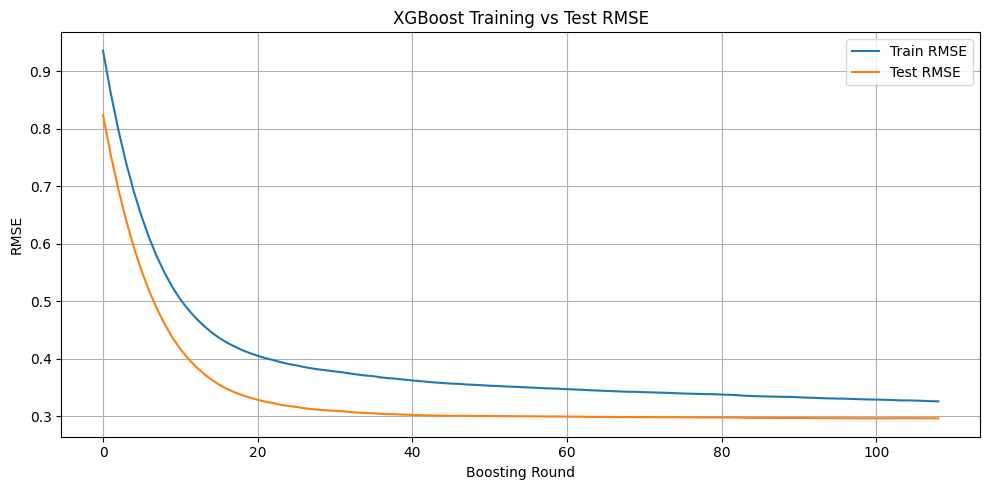

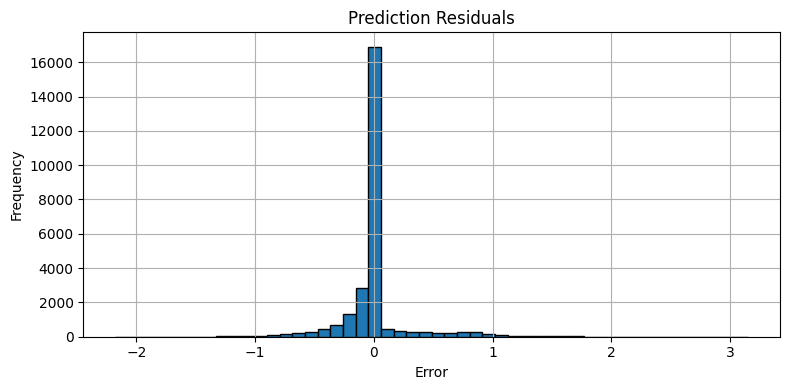

<Figure size 1000x6000 with 0 Axes>

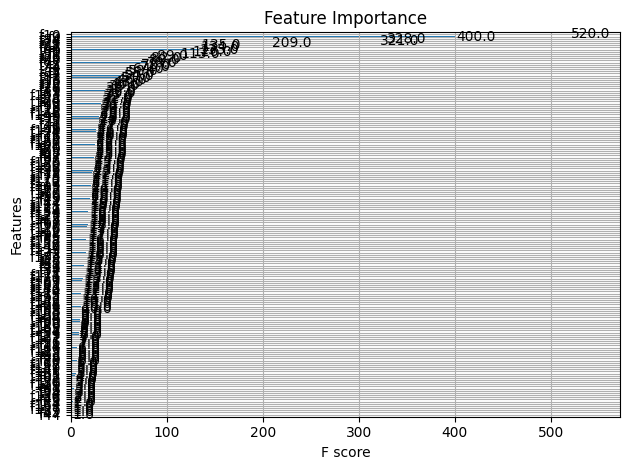

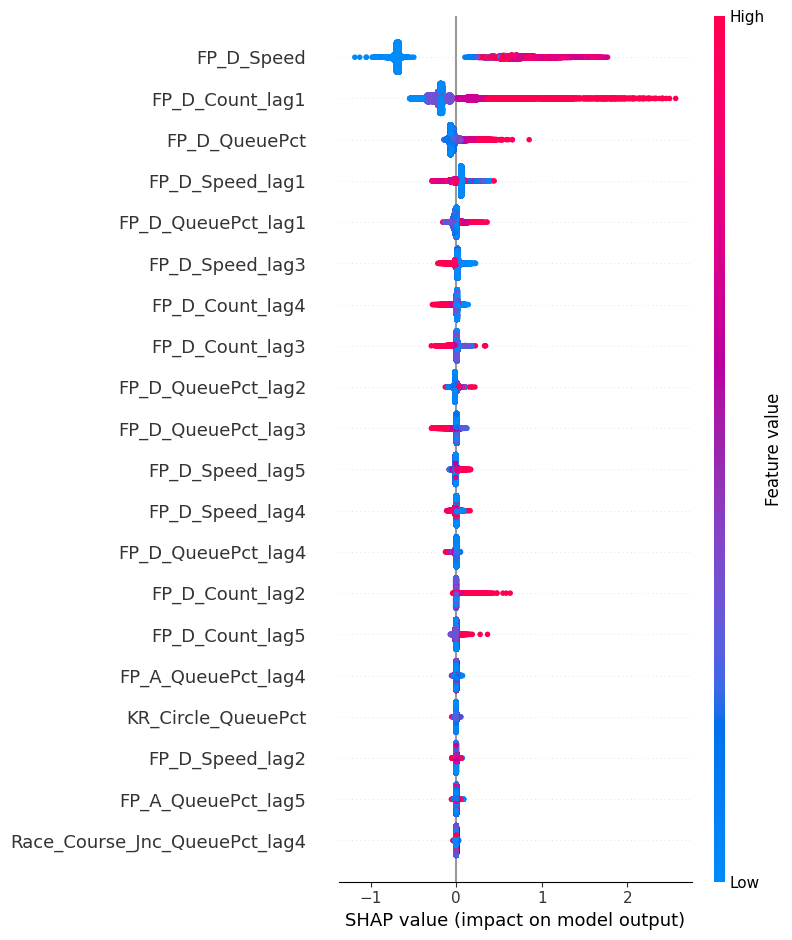

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error as mse, r2_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import shap
import xgboost as xgb

# 1. Load data
f = r'/content/junction_data_race_course (1).csv'
df = pd.read_csv(f)

# 2. Drop Time column if exists
if 'Time' in df.columns:
    df.drop(columns=['Time'], inplace=True)

# 3. Sample by averaging every sample_n rows
sample_n = 1
df = df.groupby(df.index // sample_n).mean().reset_index(drop=True)

# 4. Create all lagged features in bulk, then concat at once
n_lags = 5
lags = {}   # collect each new column as a Series

for col in df.columns:
    for lag in range(1, n_lags + 1):
        lags[f'{col}_lag{lag}'] = df[col].shift(lag)

# Convert dict to DataFrame
lags_df = pd.DataFrame(lags)

# Concatenate original + all lags in one shot
df = pd.concat([df, lags_df], axis=1)

# Optional: free fragmentation completely
df = df.copy()

# Drop rows with NaNs from the lagging
df.dropna(inplace=True)

# 5. Split into X (features) and y (target)
y = df['FP_D_Count']
X = df.drop(columns=['FP_D_Count'])

# 6. Scale features (helps model convergence and cosine similarity)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. Time-based train/test split (70/30)
split_idx = int(0.7 * len(df))
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# 8. Instantiate XGBRegressor with eval_metric & early_stopping_rounds
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.1,
    random_state=42,
    eval_metric='rmse',
    early_stopping_rounds=10
)

# 9. Fit with eval_set only
eval_set = [(X_train, y_train), (X_test, y_test)]
model.fit(X_train, y_train, eval_set=eval_set, verbose=False)

# 10. Make predictions
y_pred = model.predict(X_test)

# 11. Evaluate
rmse = np.sqrt(mse(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
cos_sim = cosine_similarity([y_test.values], [y_pred])[0][0]

# Print Evaluation Metrics
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.2f}')
print(f'Cosine Similarity: {cos_sim:.4f}')

# 12. Plot: Actual vs Predicted
plt.figure(figsize=(25,5))
plt.plot(y_test.values[::120], label='Actual', linewidth=2)
plt.plot(y_pred[::120], label='Predicted')
plt.title('FP_D_Count: Actual vs Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Vehicle Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')  # Save the plot
plt.show()

# 13. Plot: Train vs Test RMSE over boosting rounds
results = model.evals_result()
epochs = len(results['validation_0']['rmse'])
x_axis = range(epochs)

plt.figure(figsize=(10,5))
plt.plot(x_axis, results['validation_0']['rmse'], label='Train RMSE')
plt.plot(x_axis, results['validation_1']['rmse'], label='Test RMSE')
plt.title('XGBoost Training vs Test RMSE')
plt.xlabel('Boosting Round')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('train_vs_test_rmse.png')  # Save the plot
plt.show()

# 14. Plot: Residuals histogram
residuals = y_test - y_pred
plt.figure(figsize=(8,4))
plt.hist(residuals, bins=50, edgecolor='black')
plt.title('Prediction Residuals')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.savefig('residuals_histogram.png')  # Save the plot
plt.show()

# 15. Feature Importance Plot (using XGBoost's plot_importance)
plt.figure(figsize=(10,60))
xgb.plot_importance(model, importance_type='weight', max_num_features=len(X.columns))
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')  # Save the plot
plt.show()

# 16. SHAP Summary Plot
X_train_df = pd.DataFrame(X_train, columns=X.columns)

# Create SHAP explainer with the original data and the model
explainer = shap.Explainer(model)

# Get SHAP values
shap_values = explainer(X_train_df)

# SHAP summary plot
shap.summary_plot(shap_values, X_train_df)
plt.savefig('shap_summary_plot.png')  # Save the plot
plt.show()


In [ ]:
X

,FP_A_Count,FP_A_QueuePct,FP_A_Speed,FP_B_Count,FP_B_QueuePct,FP_B_Speed,FP_C_Count,FP_C_QueuePct,FP_C_Speed,FP_D_QueuePct,...,Palace_Road_Jnc_Speed_lag1,Palace_Road_Jnc_Speed_lag2,Palace_Road_Jnc_Speed_lag3,Palace_Road_Jnc_Speed_lag4,Palace_Road_Jnc_Speed_lag5,Palace_Road_Jnc_Speed_lag6,Palace_Road_Jnc_Speed_lag7,Palace_Road_Jnc_Speed_lag8,Palace_Road_Jnc_Speed_lag9,Palace_Road_Jnc_Speed_lag10
10,0.0,0.000,0.000,0.0,0.000,0.00,0.0,0.0,0.0,0.00,...,0.000,0.000,0.000,0.000,12.020,7.825,6.910,2.975,0.000,0.000
11,0.0,0.000,0.000,0.0,0.000,0.00,0.0,0.0,0.0,0.00,...,7.230,0.000,0.000,0.000,0.000,12.020,7.825,6.910,2.975,0.000
12,0.0,0.000,0.000,0.0,0.000,0.00,0.0,0.0,0.0,0.00,...,5.855,7.230,0.000,0.000,0.000,0.000,12.020,7.825,6.910,2.975
13,0.0,0.000,0.000,0.0,0.000,0.00,0.0,0.0,0.0,0.00,...,6.515,5.855,7.230,0.000,0.000,0.000,0.000,12.020,7.825,6.910
14,0.0,0.000,0.000,0.0,0.000,0.00,0.0,0.0,0.0,0.00,...,5.555,6.515,5.855,7.230,0.000,0.000,0.000,0.000,12.020,7.825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43195,1.0,0.270,6.260,0.0,0.050,0.00,0.0,0.0,0.0,0.09,...,5.735,4.380,7.975,7.865,7.495,5.755,10.050,6.730,7.265,5.350
43196,1.0,0.850,7.965,0.0,0.080,0.00,0.0,0.0,0.0,0.09,...,7.615,5.735,4.380,7.975,7.865,7.495,5.755,10.050,6.730,7.265
43197,1.0,0.105,9.645,0.0,0.080,0.00,0.0,0.0,0.0,0.09,...,10.305,7.615,5.735,4.380,7.975,7.865,7.495,5.755,10.050,6.730
43198,0.0,0.090,0.000,0.5,0.080,9.49,0.0,0.0,0.0,0.09,...,7.575,10.305,7.615,5.735,4.380,7.975,7.865,7.495,5.755,10.050


RMSE: 0.32
R² Score: 0.87
Cosine Similarity: 0.9551


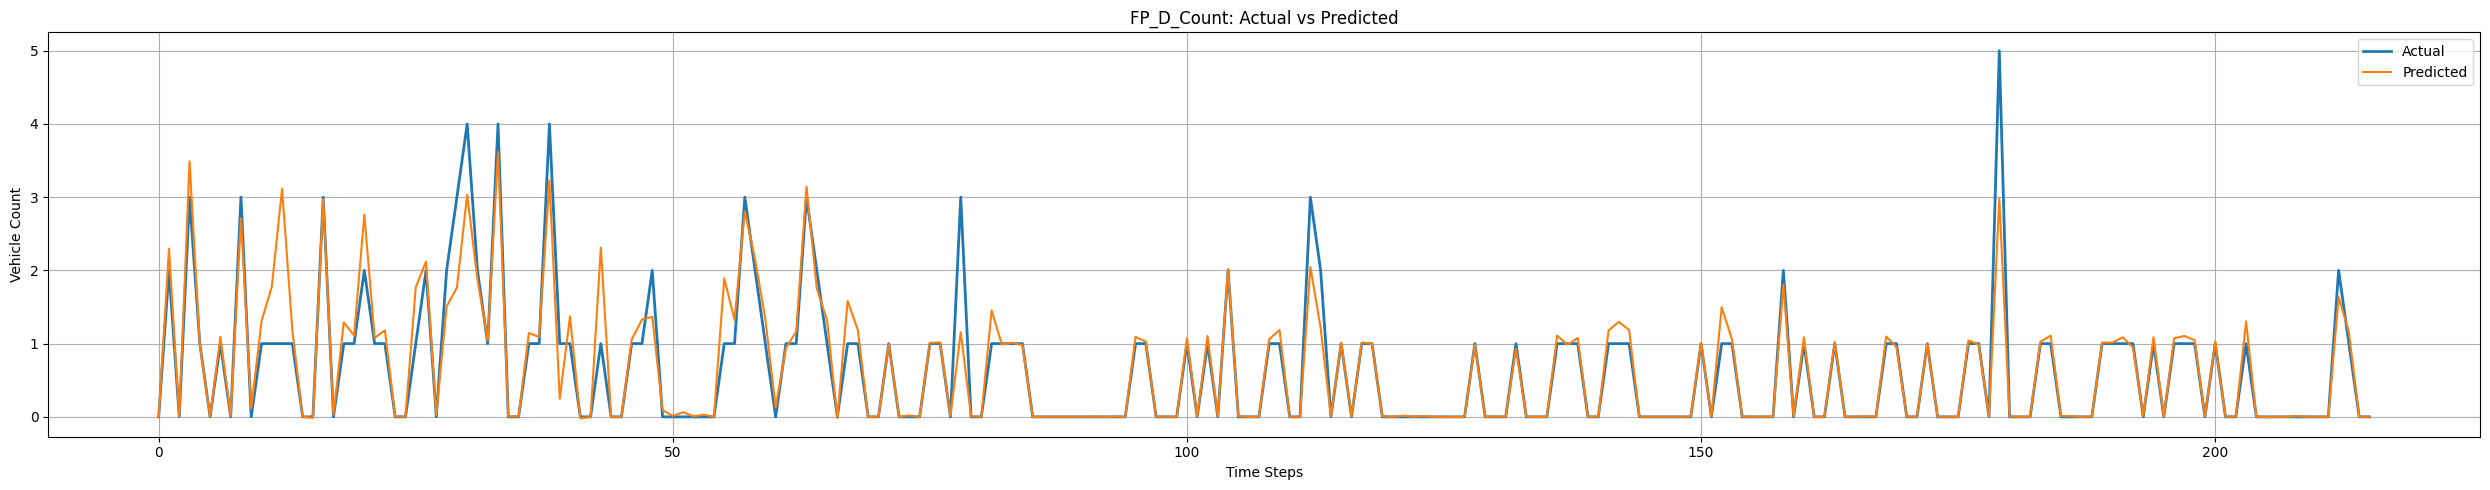

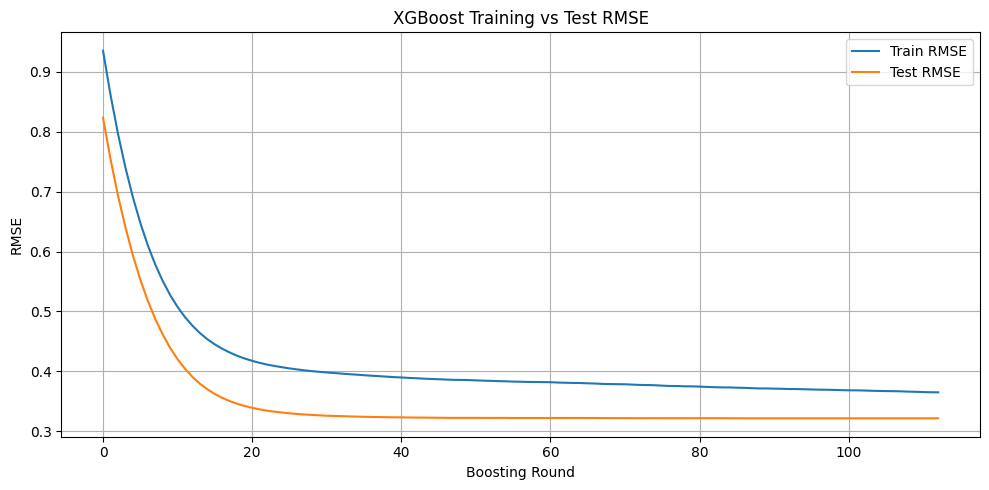

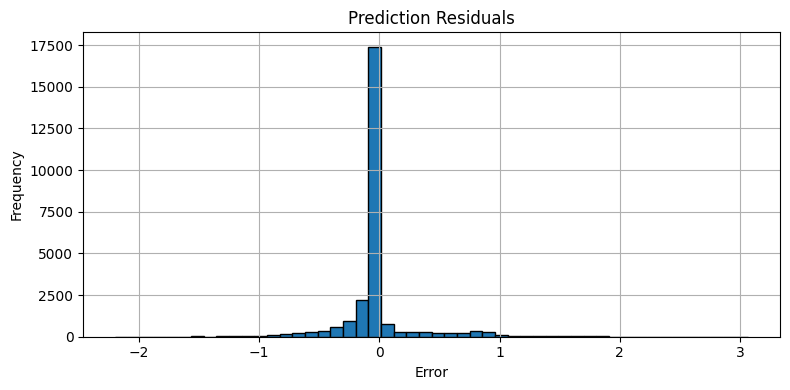

<Figure size 1000x6000 with 0 Axes>

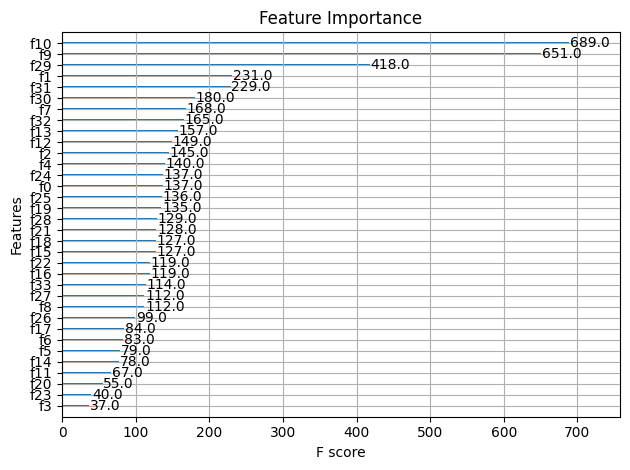

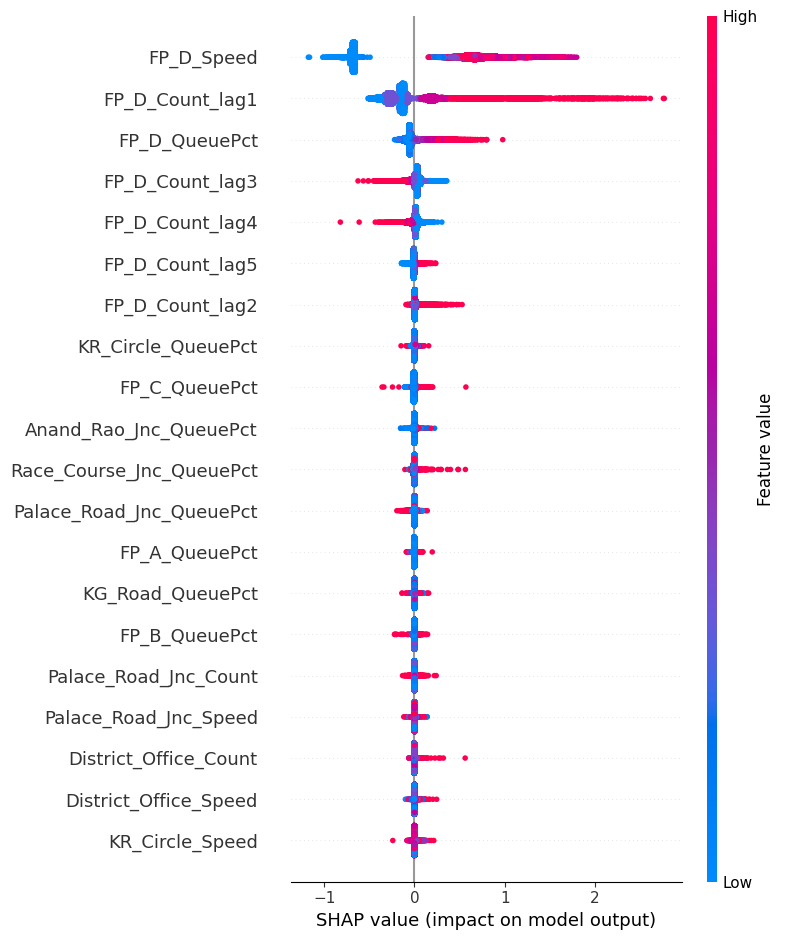

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error as mse, r2_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import shap
import xgboost as xgb

# 1. Load data
f = r'/content/junction_data_race_course (1).csv'
df = pd.read_csv(f)

# 2. Drop Time column if exists
if 'Time' in df.columns:
    df.drop(columns=['Time'], inplace=True)

# 3. Sample by averaging every sample_n rows
sample_n = 1
df = df.groupby(df.index // sample_n).mean().reset_index(drop=True)

# 4. Create lag features for FP_D_Count
n_lags = 5
for lag in range(1, n_lags + 1):
    df[f'FP_D_Count_lag{lag}'] = df['FP_D_Count'].shift(lag)
df.dropna(inplace=True)  # remove rows with NaNs from shifting

# 5. Split into X (features) and y (target)
y = df['FP_D_Count']
X = df.drop(columns=['FP_D_Count'])

# 6. Scale features (helps model convergence and cosine similarity)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. Time-based train/test split (70/30)
split_idx = int(0.7 * len(df))
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# 8. Instantiate XGBRegressor with eval_metric & early_stopping_rounds
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.1,
    random_state=42,
    eval_metric='rmse',
    early_stopping_rounds=10
)

# 9. Fit with eval_set only
eval_set = [(X_train, y_train), (X_test, y_test)]
model.fit(X_train, y_train, eval_set=eval_set, verbose=False)

# 10. Make predictions
y_pred = model.predict(X_test)

# 11. Evaluate
rmse = np.sqrt(mse(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
cos_sim = cosine_similarity([y_test.values], [y_pred])[0][0]

# Print Evaluation Metrics
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.2f}')
print(f'Cosine Similarity: {cos_sim:.4f}')

# 12. Plot: Actual vs Predicted
plt.figure(figsize=(25,5))
plt.plot(y_test.values[::120], label='Actual', linewidth=2)
plt.plot(y_pred[::120], label='Predicted')
plt.title('FP_D_Count: Actual vs Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Vehicle Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')  # Save the plot
plt.show()

# 13. Plot: Train vs Test RMSE over boosting rounds
results = model.evals_result()
epochs = len(results['validation_0']['rmse'])
x_axis = range(epochs)

plt.figure(figsize=(10,5))
plt.plot(x_axis, results['validation_0']['rmse'], label='Train RMSE')
plt.plot(x_axis, results['validation_1']['rmse'], label='Test RMSE')
plt.title('XGBoost Training vs Test RMSE')
plt.xlabel('Boosting Round')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('train_vs_test_rmse.png')  # Save the plot
plt.show()

# 14. Plot: Residuals histogram
residuals = y_test - y_pred
plt.figure(figsize=(8,4))
plt.hist(residuals, bins=50, edgecolor='black')
plt.title('Prediction Residuals')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.savefig('residuals_histogram.png')  # Save the plot
plt.show()

# 15. Feature Importance Plot (using XGBoost's plot_importance)
plt.figure(figsize=(10,60))
xgb.plot_importance(model, importance_type='weight', max_num_features=len(X.columns))
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')  # Save the plot
plt.show()

# 16. SHAP Summary Plot
X_train_df = pd.DataFrame(X_train, columns=X.columns)

# Create SHAP explainer with the original data and the model
explainer = shap.Explainer(model)

# Get SHAP values
shap_values = explainer(X_train_df)

# SHAP summary plot
shap.summary_plot(shap_values, X_train_df)
plt.savefig('shap_summary_plot.png')  # Save the plot
plt.show()


#CONCLUSION:


1.   Warm start with accumulated is best
2.   Omitting nona adjacent nodes doesnt help here (need to expand network and see if results imporove)
3. Other features lag seems to help

